# NBA Player Injury Risk Profiling (Player-Week Dynamic Model)

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import joblib

# Step 1: Load Data

In [4]:
import pandas as pd
from datetime import timedelta

# Load your data
data = pd.read_csv('player_week_data_final.csv', parse_dates=['cutoff_date'])
injuries = pd.read_csv('player_injures_2010-2025.csv', parse_dates=['Date'])

# Create consistent name columns
data['full_name'] = data['firstName'] + ' ' + data['lastName']
injuries['full_name'] = injuries['Relinquished']


# Step 2: Label Injuries

In [39]:
import pandas as pd
from datetime import timedelta

def label_injuries_this_week(data: pd.DataFrame, injuries: pd.DataFrame) -> pd.DataFrame:
    """
    Labels each player-week with 1 if the player was injured during the 7-day week ending at their cutoff_date.
    Both name and injury date must match within the correct window.
    """

    # Step 1: Normalize dates to remove time components
    data = data.copy()
    injuries = injuries.copy()
    data['cutoff_date'] = pd.to_datetime(data['cutoff_date']).dt.normalize()
    injuries['Date'] = pd.to_datetime(injuries['Date']).dt.normalize()

    # Step 2: Standardize names to lowercase and trimmed
    data['full_name'] = data['full_name'].str.strip().str.lower()
    injuries['full_name'] = injuries['Relinquished'].str.strip().str.lower()

    # Step 3: Build fast lookup dictionary: player → list of injury dates
    injury_weeks = injuries.groupby('full_name')['Date'].apply(list).to_dict()

    # Step 4: Apply logic per row
    labels = []
    for idx, row in data.iterrows():
        full_name = row['full_name']
        cutoff = row['cutoff_date']
        start_of_week = cutoff - timedelta(days=6)

        # Check if any injury occurred within the same week
        player_injuries = injury_weeks.get(full_name, [])
        injured_this_week = any(start_of_week <= d <= cutoff for d in player_injuries)

        labels.append(int(injured_this_week))

    data['injured_this_week'] = labels

    return data

def print_label_distribution(y, name="Labels"):
    """
    Prints the number and percentage of each class (0 and 1) in the label array or Series.
    """
    from collections import Counter

    counter = Counter(y)
    total = len(y)
    print(f"\n=== {name} Distribution ===")
    for label in sorted(counter):
        count = counter[label]
        pct = 100 * count / total
        print(f"Label {label}: {count:,} ({pct:.2f}%)")


data = label_injuries_this_week(data, injuries)


# Check label balance
print_label_distribution(data['injured_this_week'], name="Injury Labels")



=== Injury Labels Distribution ===
Label 0: 317,789 (96.81%)
Label 1: 10,488 (3.19%)


# Step 3: Prepare X and Y

In [64]:
from sklearn.preprocessing import StandardScaler

# Features used for prediction
feature_cols = [
    'games_played', 'avg_minutes', 'avg_points', 'avg_assists', 'avg_rebounds',
    'rolling5_minutes', 'rolling5_points', 'back_to_back_games',
    'injury_count', 'height_inches', 'weight', 'age'
]

# Drop rows with missing values
X = data[feature_cols].dropna()
y = data.loc[X.index, 'injured_this_week']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)



# Step 4: Train Models

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# Correct class weights
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
xgb_model = XGBClassifier(eval_metric='logloss', scale_pos_weight=pos_weight, random_state=42, use_label_encoder=False)

# Define balanced models
models = {
    "Logistic Regression (balanced)": log_model,
    "Random Forest (balanced)": rf_model,
    "XGBoost (weighted)": xgb_model
}

# Store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    
    auc = roc_auc_score(y_test, probs)
    results.append({'Model': name, 'ROC AUC': auc})

# Summary Table
results_df = pd.DataFrame(results)
print("\n=== Model Comparison Summary ===")
print(results_df.sort_values(by="ROC AUC", ascending=False))



=== Logistic Regression (balanced) ===
              precision    recall  f1-score   support

           0       0.98      0.71      0.82     57050
           1       0.07      0.63      0.13      2005

    accuracy                           0.71     59055
   macro avg       0.53      0.67      0.48     59055
weighted avg       0.95      0.71      0.80     59055

Confusion Matrix:
 [[40531 16519]
 [  745  1260]]

=== Random Forest (balanced) ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     57050
           1       0.04      0.03      0.03      2005

    accuracy                           0.94     59055
   macro avg       0.50      0.50      0.50     59055
weighted avg       0.93      0.94      0.94     59055

Confusion Matrix:
 [[55626  1424]
 [ 1947    58]]


/opt/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [12:58:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost (weighted) ===
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     57050
           1       0.09      0.59      0.15      2005

    accuracy                           0.77     59055
   macro avg       0.53      0.68      0.51     59055
weighted avg       0.95      0.77      0.84     59055

Confusion Matrix:
 [[44369 12681]
 [  824  1181]]

=== Model Comparison Summary ===
                            Model   ROC AUC
2              XGBoost (weighted)  0.756574
0  Logistic Regression (balanced)  0.732607
1        Random Forest (balanced)  0.705382


In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, roc_auc_score

# Define AUC scorer
auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

# Logistic Regression
log_params = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs', 'liblinear']
}
log_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])
log_grid = GridSearchCV(log_pipe, log_params, scoring=auc_scorer, cv=5, n_jobs=-1)
log_grid.fit(X_train, y_train)

# Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}
rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                       rf_params, scoring=auc_scorer, cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)

# XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(XGBClassifier(scale_pos_weight=pos_weight, use_label_encoder=False,
                                      eval_metric='logloss', random_state=42),
                        xgb_params, scoring=auc_scorer, cv=5, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

# Print best results
print("\nBest Logistic Regression:", log_grid.best_params_)
print("Best AUC:", roc_auc_score(y_test, log_grid.predict_proba(X_test)[:, 1]))

print("\nBest Random Forest:", rf_grid.best_params_)
print("Best AUC:", roc_auc_score(y_test, rf_grid.predict_proba(X_test)[:, 1]))

print("\nBest XGBoost:", xgb_grid.best_params_)
print("Best AUC:", roc_auc_score(y_test, xgb_grid.predict_proba(X_test)[:, 1]))


/opt/miniconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Best Logistic Regression: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best AUC: 0.7326871908746977

Best Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best AUC: 0.7053820094811175

Best XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best AUC: 0.7360444200629015


# Step 6: Save Trained Models

In [67]:
import joblib

joblib.dump(log_model, 'Models/log_model.pkl')
joblib.dump(rf_model, 'Models/rf_model.pkl')
joblib.dump(xgb_model, 'Models/xgb_model.pkl')

['Models/xgb_model.pkl']

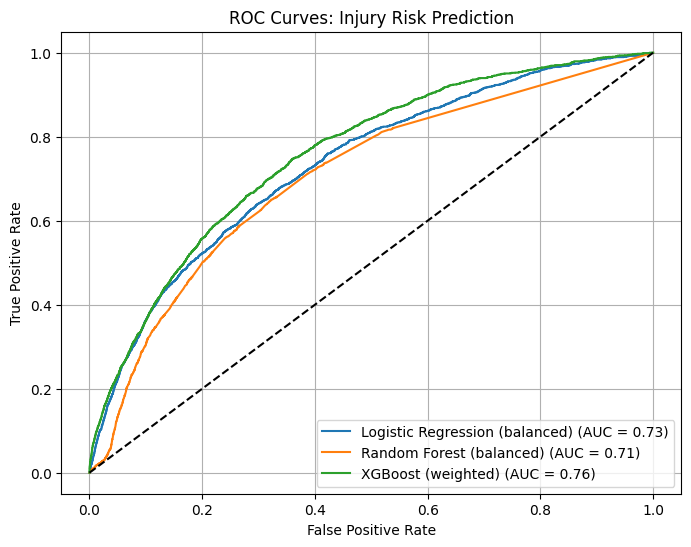

In [68]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, probs):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Injury Risk Prediction')
plt.legend()
plt.grid(True)
plt.show()
